In [ ]:
import tensorflow as tf
from tensorflow import keras
import os
import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import mnist

from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.callbacks import EarlyStopping

from keras.layers import Flatten, Conv2D, MaxPooling2D

import os
import math
from PIL import Image

seed=42
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

# Exercise 12

In [372]:
# Load the data and split in training and test
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

img_width = X_train.shape[1]
img_height = X_train.shape[2]

# Convert to 
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Rescale the input data so it's between 0 and 255
X_train = X_train / 255
X_test = X_test / 255

# Define number of classes
num_classes = 10

# Turn the labels to categorical
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)

## Exercise 12.1: Optimizers Exploration for DNN

The goal of this exercise is to explore the performance of different optimizers for a Deep Neural Network. Specifically, I compared the standard **SGD** (Stochastic Gradient Descent) with **Adam** and **RMSprop**.

Overall, all three optimizers perform similarly well, reaching an accuracy of around 98%. However, achieving stable convergence required specific hyperparameter tuning for each algorithm.

#### The Adam Optimizer
For Adam, I decreased both the default learning rate and the momentum ($\beta_1$). A lower learning rate allows the algorithm to descend the cost function's valleys more smoothly without overshooting. Lowering the momentum, on the other hand, reduces the network's "memory" of previous gradient directions. Since Adam relies on stochastic approximations of the gradient, reducing this memory ensures that initial, potentially noisy drifts are not carried forward for too long, leading to a much more stable convergence.

#### The RMSprop Optimizer
For RMSprop, my tuning focused on the learning rate, the $\rho$ parameter, and the EMA (Exponential Moving Average) momentum. 
* The **$\rho$ parameter** acts as a discounting factor, controlling how quickly the optimizer forgets the history of past squared gradients, smoothing out sudden jumps of the gradients due to "unlucky" batches.
* The **EMA momentum** ($\alpha$) smooths out the updates of the model's parameters ($\theta$) over time using a moving average formula:

$$\theta_{\text{new}} \leftarrow \alpha \theta_{\text{old}} + (1-\alpha) \theta_{\text{current}}$$

While experimenting, I found that tweaking the EMA momentum from its default value (0.99) to higher (0.999) or lower (0.9) values did not significantly alter the overall performance. For the final run, I decided to keep $\rho = 0.9$ and EMA momentum = 0.99, as this configuration provided the slightly best outcome. Ultimately, Adam turned out to be the best-performing optimizer overall, albeit by a very small margin.

#### The Crucial Role of the Learning Rate
The most critical parameter across all optimizers proved to be the learning rate. The landscape of the cost function likely features very narrow valleys: using larger learning rates causes the optimizer to bounce between the walls of the minimum, producing highly unstable and noisy results. Here is an example of a run using RMSprop with a learning rate of 0.001 (the same noisy behavior was observed with Adam):

<table>
  <tr>
    <td><img src="accuracy-RMSprop-bigLR.png" alt="Accuracy" width="100%"></td>
    <td><img src="loss-RMSprop-bigLR.png" alt="Loss" width="100%"></td>
  </tr>
</table>

By simply lowering the learning rate to 0.0001 (while keeping other hyperparameters constant, e.g., $\rho = 0.8$ and EMA momentum = 0.7), the training curves became dramatically smoother, and the model's sensitivity to the tuning of other parameters was greatly reduced.

<table>
  <tr>
    <td><img src="accuracy-RMSprop-smallLR.png" alt="Accuracy" width="100%"></td>
    <td><img src="loss-RMSprop-smallLR.png" alt="Loss" width="100%"></td>
  </tr>
</table>

### Compilation and training of the models

In [373]:
# Have to reshape the data to array form and convert to float32
X_train_DNN = X_train.reshape(X_train.shape[0], img_width*img_height)
X_test_DNN = X_test.reshape(X_test.shape[0], img_width*img_height)

# Helper function to create a DNN
def create_DNN():
    # instantiate model
    model = Sequential()
    model.add(Input(shape=(img_width*img_height,)))
    # add a dense all-to-all relu layer
    model.add(Dense(400, activation='relu'))
    # add a dense all-to-all relu layer
    model.add(Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(Dropout(0.5))
    # soft-max layer
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

In [374]:
# Create a model and print the summary
model = create_DNN()
model.summary()

Model: "sequential_101"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_305 (Dense)               │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_306 (Dense)               │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_94 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_307 (Dense)               │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,110 (1.35 MB)

 Trainable params: 355,110 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [375]:
# Helper function to compile the model
def compile_model_SGD():
    model = create_DNN()
    model.compile(
        loss=keras.losses.categorical_crossentropy,
        optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.0),
        metrics=["acc"]
    )
    return model

def compile_model_adam():
    model = create_DNN()
    model.compile(
        loss=keras.losses.categorical_crossentropy,
        optimizer=keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5),
        metrics=["acc"]
    )
    return model

def compile_model_RMSprop():
    model = create_DNN()
    model.compile(
        loss=keras.losses.categorical_crossentropy,
        optimizer=keras.optimizers.RMSprop(learning_rate=0.0001, rho=0.9, ema_momentum=0.99),
        metrics=["acc"]
    )
    return model

In [376]:
# Create and train the model
batch_size = 32
epochs = 40

model_DNN_SGD = compile_model_SGD()
print("Optimization with SGD")
history_DNN_SGD = model_DNN_SGD.fit(X_train_DNN, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True,
          verbose=1,
          validation_data=(X_test_DNN, Y_test))

model_DNN_adam = compile_model_adam()
print("Optimization with Adam")
callback = keras.callbacks.EarlyStopping(monitor='loss', patience=5)
history_DNN_adam = model_DNN_adam.fit(X_train_DNN, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True,
          callbacks=[callback],
          verbose=1,
          validation_data=(X_test_DNN, Y_test))

model_DNN_RMSprop = compile_model_RMSprop()
print("Optimization with RMSprop")
callback = keras.callbacks.EarlyStopping(monitor='loss', patience=5)
history_DNN_RMSprop = model_DNN_RMSprop.fit(X_train_DNN, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True,
          callbacks=[callback],
          verbose=1,
          validation_data=(X_test_DNN, Y_test))

Optimization with SGD
Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 836us/step - acc: 0.7766 - loss: 0.7601 - val_acc: 0.9137 - val_loss: 0.3139
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 763us/step - acc: 0.8898 - loss: 0.3835 - val_acc: 0.9307 - val_loss: 0.2421
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - acc: 0.9110 - loss: 0.3139 - val_acc: 0.9407 - val_loss: 0.2016
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 799us/step - acc: 0.9240 - loss: 0.2684 - val_acc: 0.9461 - val_loss: 0.1790
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 857us/step - acc: 0.9330 - loss: 0.2374 - val_acc: 0.9528 - val_loss: 0.1585
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 855us/step - acc: 0.9406 - loss: 0.2110 - val_acc: 0.9553 - val_loss: 0.1450
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 813us/step - acc: 0.9463 - loss: 0.1922 - val_acc: 0.9588 - val_loss: 0.1341
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 785us/step - acc: 0.9502 - loss: 0.1762 - val_acc: 0.9609 - val_loss: 0.1235
Ep

### Results SGD

------------- Performance metrics - SGD -------------
Test loss - SGD: 0.06188385188579559
Test accuracy - SGD: 0.9803000092506409


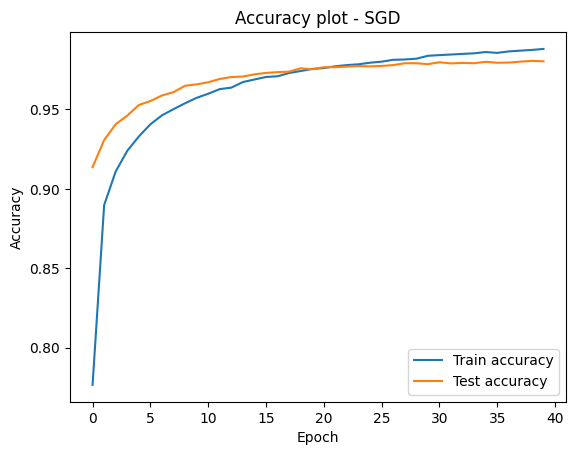

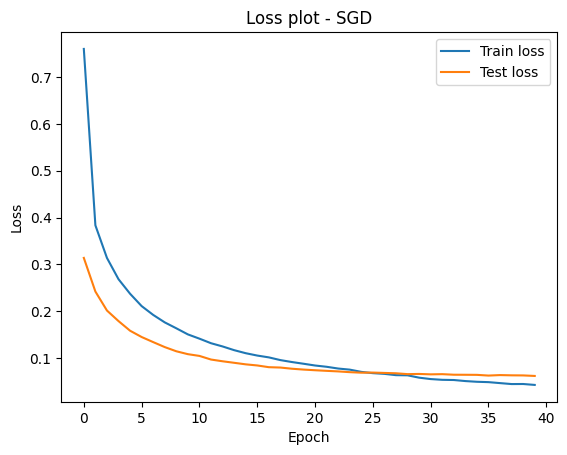

In [377]:
# Evaluate the model
score_SGD = model_DNN_SGD.evaluate(X_test_DNN, Y_test, verbose=0)

print('------------- Performance metrics - SGD -------------')
print('Test loss - SGD:', score_SGD[0])
print('Test accuracy - SGD:', score_SGD[1])

# Plot accuracy
plt.plot(history_DNN_SGD.history['acc'], label='Train accuracy')
plt.plot(history_DNN_SGD.history['val_acc'], label='Test accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title("Accuracy plot - SGD")
plt.legend(loc='best')
plt.show()

# Plot loss
plt.plot(history_DNN_SGD.history['loss'], label='Train loss')
plt.plot(history_DNN_SGD.history['val_loss'], label='Test loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title("Loss plot - SGD")
plt.legend(loc='best')
plt.show()

### Results ADAM

------------- Performance metrics - Adam -------------
Test loss - Adam: 0.08164942264556885
Test accuracy - Adam: 0.982699990272522


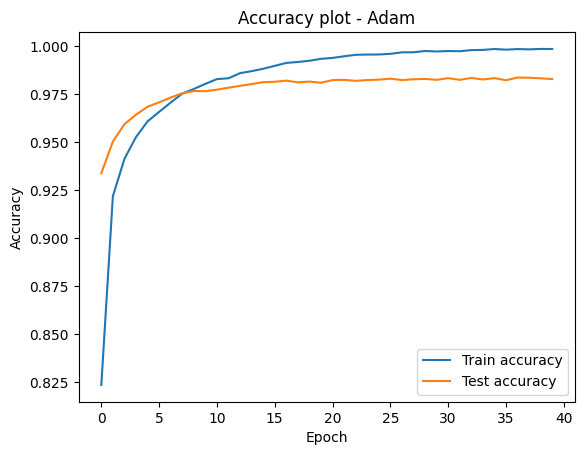

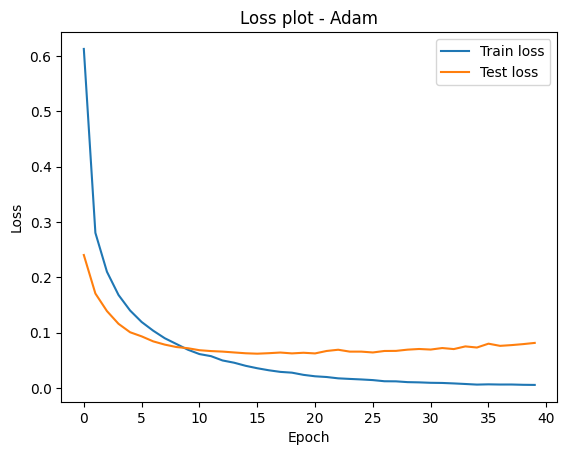

In [378]:
# Evaluate the model
score_adam = model_DNN_adam.evaluate(X_test_DNN, Y_test, verbose=0)

print('------------- Performance metrics - Adam -------------')
print('Test loss - Adam:', score_adam[0])
print('Test accuracy - Adam:', score_adam[1])

# Plot accuracy
plt.plot(history_DNN_adam.history['acc'], label='Train accuracy')
plt.plot(history_DNN_adam.history['val_acc'], label='Test accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title("Accuracy plot - Adam")
plt.legend(loc='best')
plt.show()

# Plot loss
plt.plot(history_DNN_adam.history['loss'], label='Train loss')
plt.plot(history_DNN_adam.history['val_loss'], label='Test loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title("Loss plot - Adam")
plt.legend(loc='best')
plt.show()

### Results RMSprop

------------- Performance metrics - RMSprop -------------
Test loss - RMS_prop: 0.08700252324342728
Test accuracy - RMS_prop: 0.9807999730110168


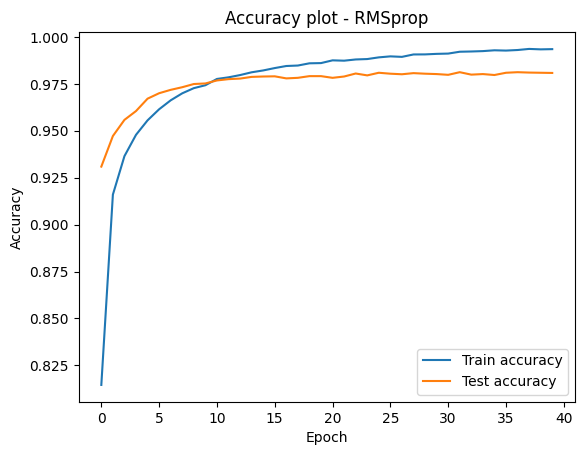

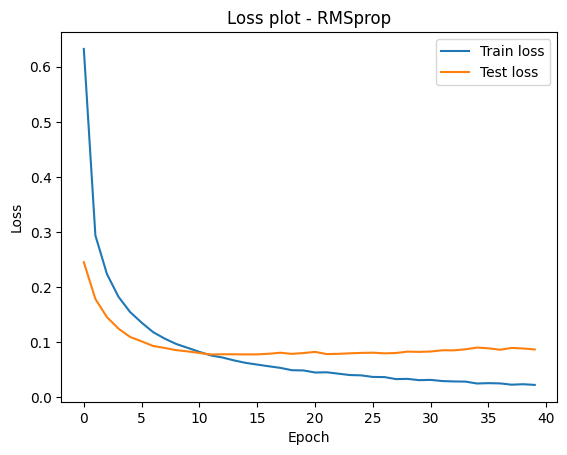

In [379]:
# Evaluate the model
score_RMSprop = model_DNN_RMSprop.evaluate(X_test_DNN, Y_test, verbose=0)

print('------------- Performance metrics - RMSprop -------------')
print('Test loss - RMS_prop:', score_RMSprop[0])
print('Test accuracy - RMS_prop:', score_RMSprop[1])

# Plot accuracy
plt.plot(history_DNN_RMSprop.history['acc'], label='Train accuracy')
plt.plot(history_DNN_RMSprop.history['val_acc'], label='Test accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title("Accuracy plot - RMSprop")
plt.legend(loc='best')
plt.show()

# Plot loss
plt.plot(history_DNN_RMSprop.history['loss'], label='Train loss')
plt.plot(history_DNN_RMSprop.history['val_loss'], label='Test loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title("Loss plot - RMSprop")
plt.legend(loc='best')
plt.show()

### Summary picture

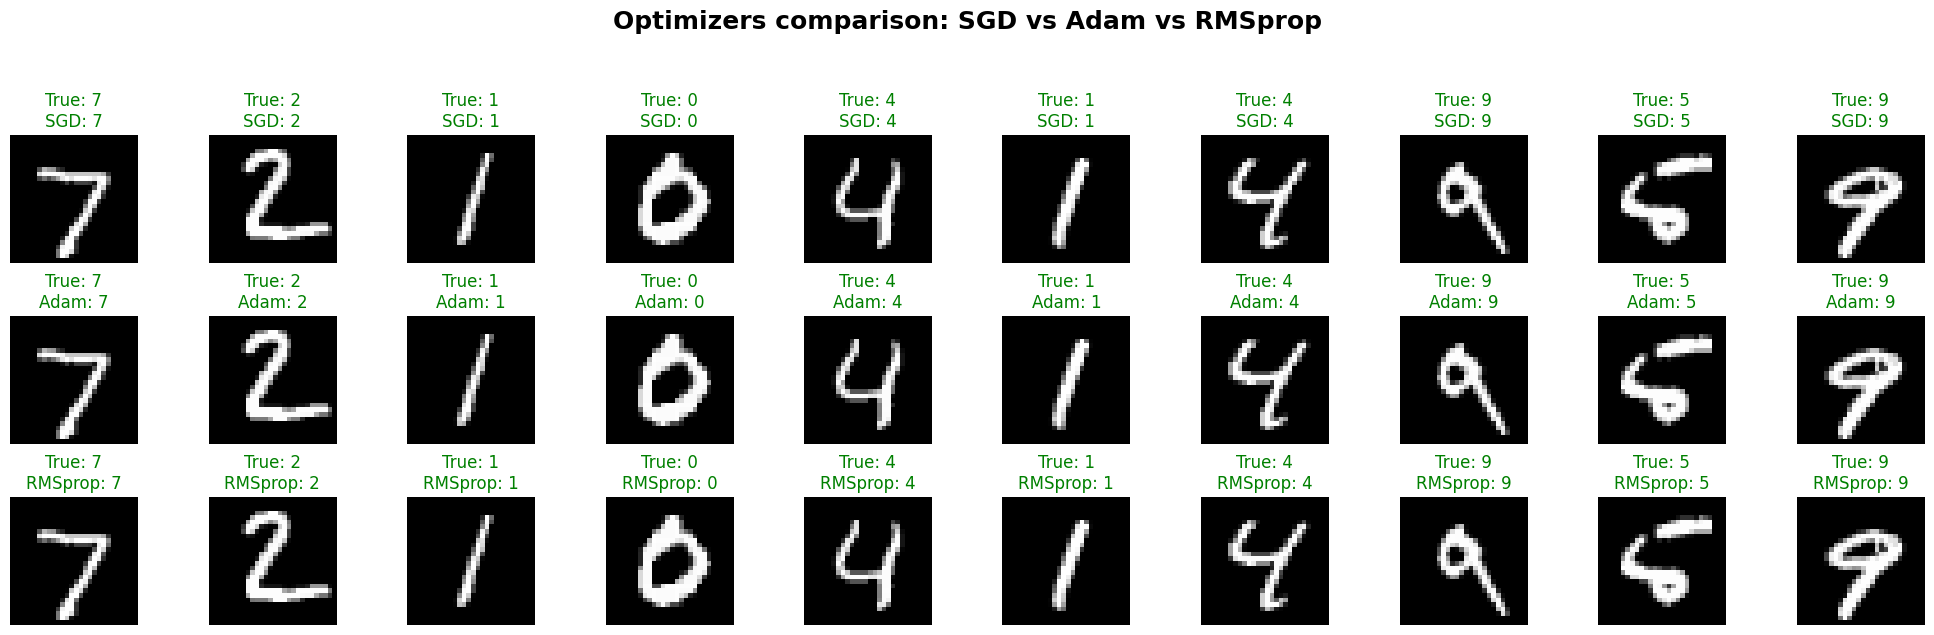

In [383]:
# Generate predictions
predictions_SGD = model_DNN_SGD.predict(X_test_DNN, verbose=0)
predictions_adam = model_DNN_adam.predict(X_test_DNN, verbose=0)
predictions_RMSprop = model_DNN_RMSprop(X_test_DNN, verbose=0)

# Reshape images for drawing
img_height, img_width = 28, 28
X_test_img = X_test_DNN.reshape(X_test_DNN.shape[0], img_height, img_width)

# Plot
plt.figure(figsize=(20, 6))
plt.suptitle("Optimizers comparison: SGD vs Adam vs RMSprop", fontsize=18, fontweight='bold', y=1.05)

# Row 1: SGD
for i in range(10):    
    plt.subplot(3, 10, i + 1)    
    plt.imshow(X_test_img[i], cmap='gray')    
    
    true = np.argmax(Y_test[i])
    pred_sgd = np.argmax(predictions_SGD[i])
    
    color = 'green' if true == pred_sgd else 'red'
    plt.title(f"True: {true}\nSGD: {pred_sgd}", color=color, fontsize=12)    
    plt.axis('off') 

# Row 2: ADAM
for i in range(10):    
    plt.subplot(3, 10, i + 11)   
    plt.imshow(X_test_img[i], cmap='gray')    
    
    true = np.argmax(Y_test[i])
    pred_adam = np.argmax(predictions_adam[i])
    
    color = 'green' if true == pred_adam else 'red'
    plt.title(f"True: {true}\nAdam: {pred_adam}", color=color, fontsize=12)    
    plt.axis('off') 

# Row 3: RMSprop
for i in range(10):    
    plt.subplot(3, 10, i + 21)   
    plt.imshow(X_test_img[i], cmap='gray')    
    
    true = np.argmax(Y_test[i])
    pred_RMSprop = np.argmax(predictions_RMSprop[i])
    
    color = 'green' if true == pred_RMSprop else 'red'
    plt.title(f"True: {true}\nRMSprop: {pred_RMSprop}", color=color, fontsize=12)    
    plt.axis('off') 

plt.tight_layout()
plt.show()

## Exercise 12.2: Convolutional Neural Network

The goal of this second part of the exercise is to build a Convolutional Neural Network (CNN) and compare its performance with the previous Feed-Forward Neural Network (DNN). 

CNNs are specifically designed for image analysis. Unlike standard dense layers that flatten the input and lose spatial structure, convolutional layers act as local filters, sliding over the image to perform **feature extraction** (detecting edges, curves, and patterns). 

Because of this architectural advantage, CNNs are expected to achieve better or comparable accuracy while drastically reducing the computational cost. A key indicator of this efficiency is the total number of trainable parameters: while our previous DNN required over **350,000 parameters** to process the 28x28 images, this new convolutional architecture accomplishes the task with only about **31,000 parameters** — an order of magnitude less. This inherently leads to faster training times per epoch and a much lower risk of overfitting the spatial noise.

The performance of the CNN turns out to be better than the simple DNN, with a validation accuracy of almost 99%.

In [407]:
# Reshape data, depending on Keras backend
if keras.backend.image_data_format() == 'channels_first':
    X_train_CNN = X_train.reshape(X_train.shape[0], 1, img_height, img_width)
    X_test_CNN = X_test.reshape(X_test.shape[0], 1, img_height, img_width)
    input_shape = (1, img_height, img_width)
else:
    X_train_CNN = X_train.reshape(X_train.shape[0], img_height, img_width, 1)
    X_test_CNN = X_test.reshape(X_test.shape[0], img_height, img_width, 1)
    input_shape = (img_height, img_width, 1)

In [408]:
def create_CNN():
    model = Sequential()
    
    # Input: 28x28 -> Output: 24x24
    model.add(Conv2D(10, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1)))
    
    # Output: 12x12
    model.add(MaxPooling2D((2, 2))) 
    
    # Output: 10x10
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
    
    # 4. Output: 5x5
    model.add(MaxPooling2D((2, 2)))
    
    # Output: 3x3
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))

    # Flatten
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.6),
                  metrics=['acc'])
    return model

In [409]:
batch_size = 32
epochs = 40

model_CNN = create_CNN()

model_CNN.summary()

history_CNN = model_CNN.fit(X_train_CNN, Y_train,
                            batch_size=batch_size,
                            epochs=epochs,
                            shuffle=True,
                            verbose=1,
                            validation_data=(X_test_CNN, Y_test)
)

/Applications/anaconda3/envs/SimulazioneNumerica/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_110"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 10, 10, 32)     │         2,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 3, 3, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_323 (Dense)               │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_324 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,566 (123.30 KB)

 Trainable params: 31,566 (123.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - acc: 0.8494 - loss: 0.5285 - val_acc: 0.9398 - val_loss: 0.1988
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9489 - loss: 0.1714 - val_acc: 0.9601 - val_loss: 0.1280
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9630 - loss: 0.1236 - val_acc: 0.9678 - val_loss: 0.1005
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9697 - loss: 0.1008 - val_acc: 0.9732 - val_loss: 0.0845
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9735 - loss: 0.0866 - val_acc: 0.9777 - val_loss: 0.0733
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9765 - loss: 0.0766 - val_acc: 0.9786 - val_loss: 0.0657
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9791 - loss: 0.0690 - val_acc: 0.9801 - val_loss: 0.0602
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9811 - loss: 0.0631 - val_acc: 0.9812 - val_loss: 0.0560
Epoch 9/40
1875/1875 ━━━━━━━━━━━━━━━━━━━

------------- Performance metrics - CNN -------------
Test loss - CNN: 0.03841416910290718
Test accuracy - CNN: 0.9882000088691711


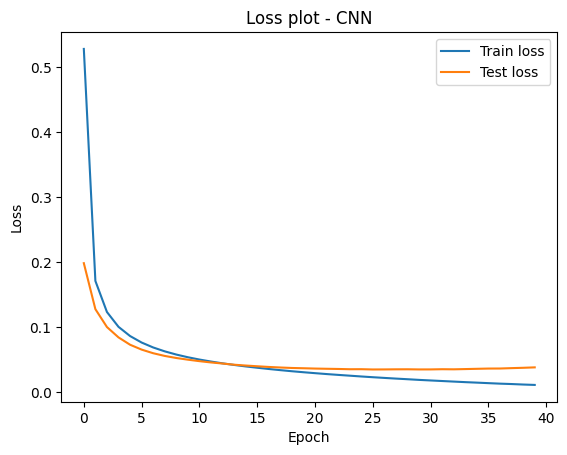

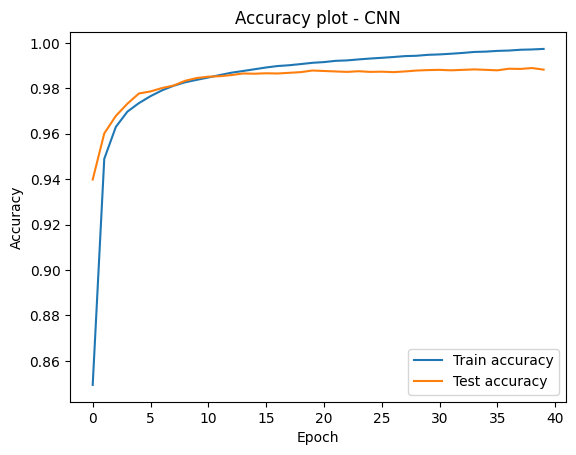

In [410]:
# Evaluate the model
score_CNN = model_CNN.evaluate(X_test_CNN, Y_test, verbose=0)

print('------------- Performance metrics - CNN -------------')
print('Test loss - CNN:', score_CNN[0])
print('Test accuracy - CNN:', score_CNN[1])

# Plot loss
plt.plot(history_CNN.history['loss'], label='Train loss')
plt.plot(history_CNN.history['val_loss'], label='Test loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title("Loss plot - CNN")
plt.legend(loc='best')
plt.show()

# Plot accuracy
plt.plot(history_CNN.history['acc'], label='Train accuracy')
plt.plot(history_CNN.history['val_acc'], label='Test accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title("Accuracy plot - CNN")
plt.legend(loc='best')
plt.show()

## Exercise 12.3: Testing with Custom Handwritten Digits

In this final part of the exercise, I tested the generalization capabilities of the trained networks using entirely new, self-generated data. Using the GIMP image editor, I manually drew some handwritten digits, imported them into the notebook, and fed them to the previously trained models to see if they could accurately recognize them.

The results highlight an interesting limitation: the networks fail to recognize some of the digits. This drop in performance is due to the fact that my handwriting style and the spatial distribution of the pixels differ from the ones in the MNIST dataset. For instance, my drawn numbers tend to be larger, causing some of the pixels near the borders of the 28x28 grid to be colored. 

Since the networks were exclusively trained on MNIST images—where the digits are strictly centered and surrounded by a consistent black margin—they are highly sensitive to these spatial variations. The models learned to expect black pixels at the borders; encountering white pixels there confuses the networks, showing how they struggle with *out-of-distribution* data that they have never seen during training.

All the networks struggles and fail consistently when the numbers are written in the corners of the picture. This is another way to see the incapacity of the networks to extend the predictions outside the domain of the training data, that we have seen in the regression problem in `Lab11`.

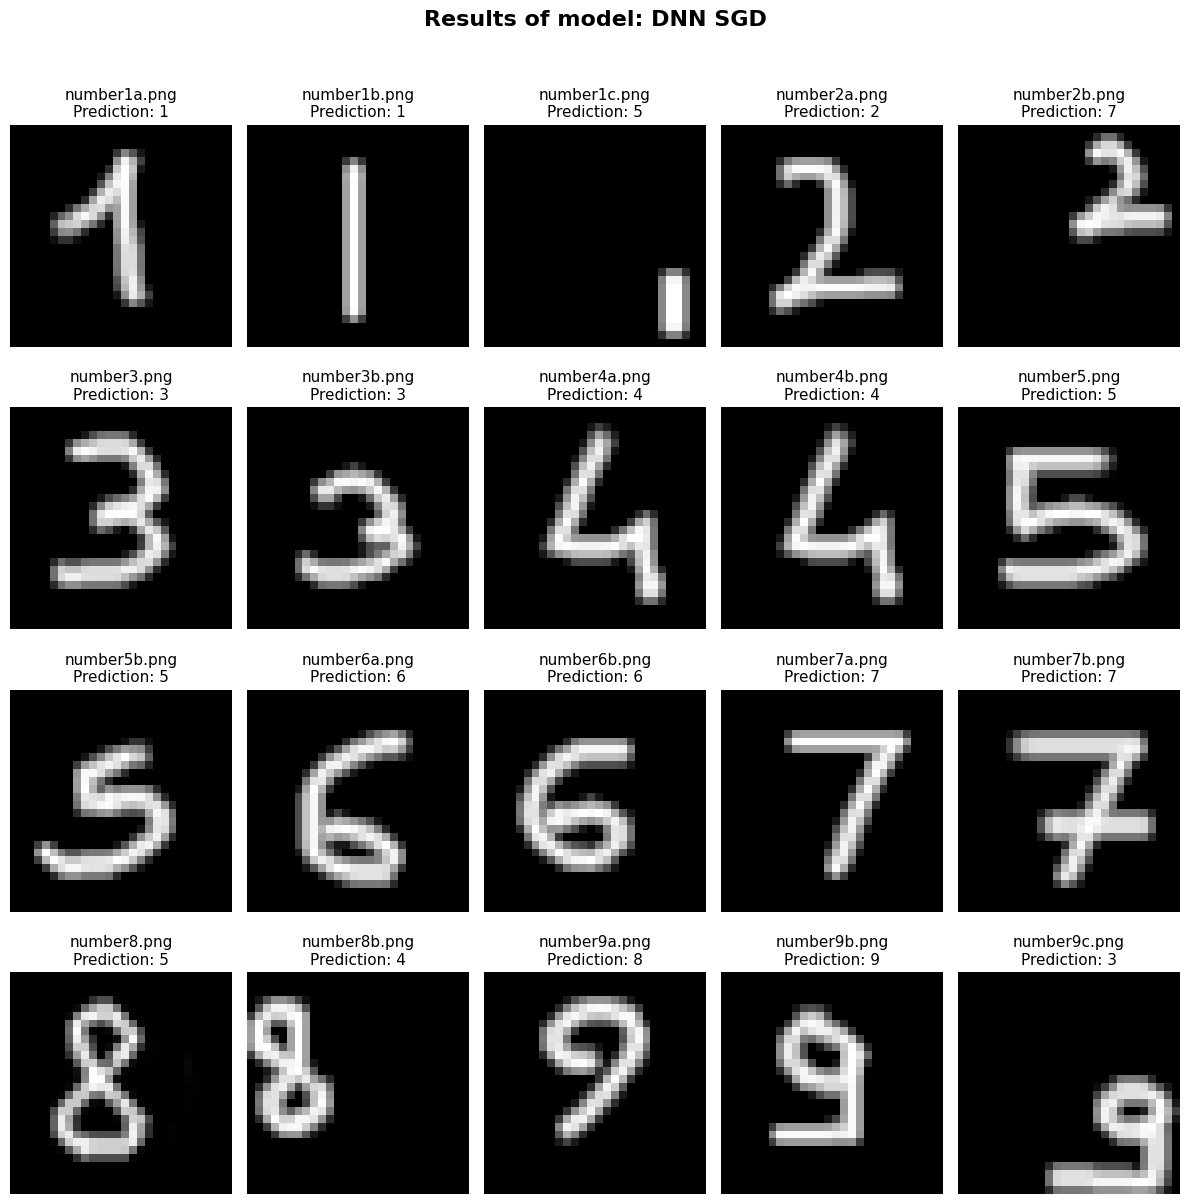

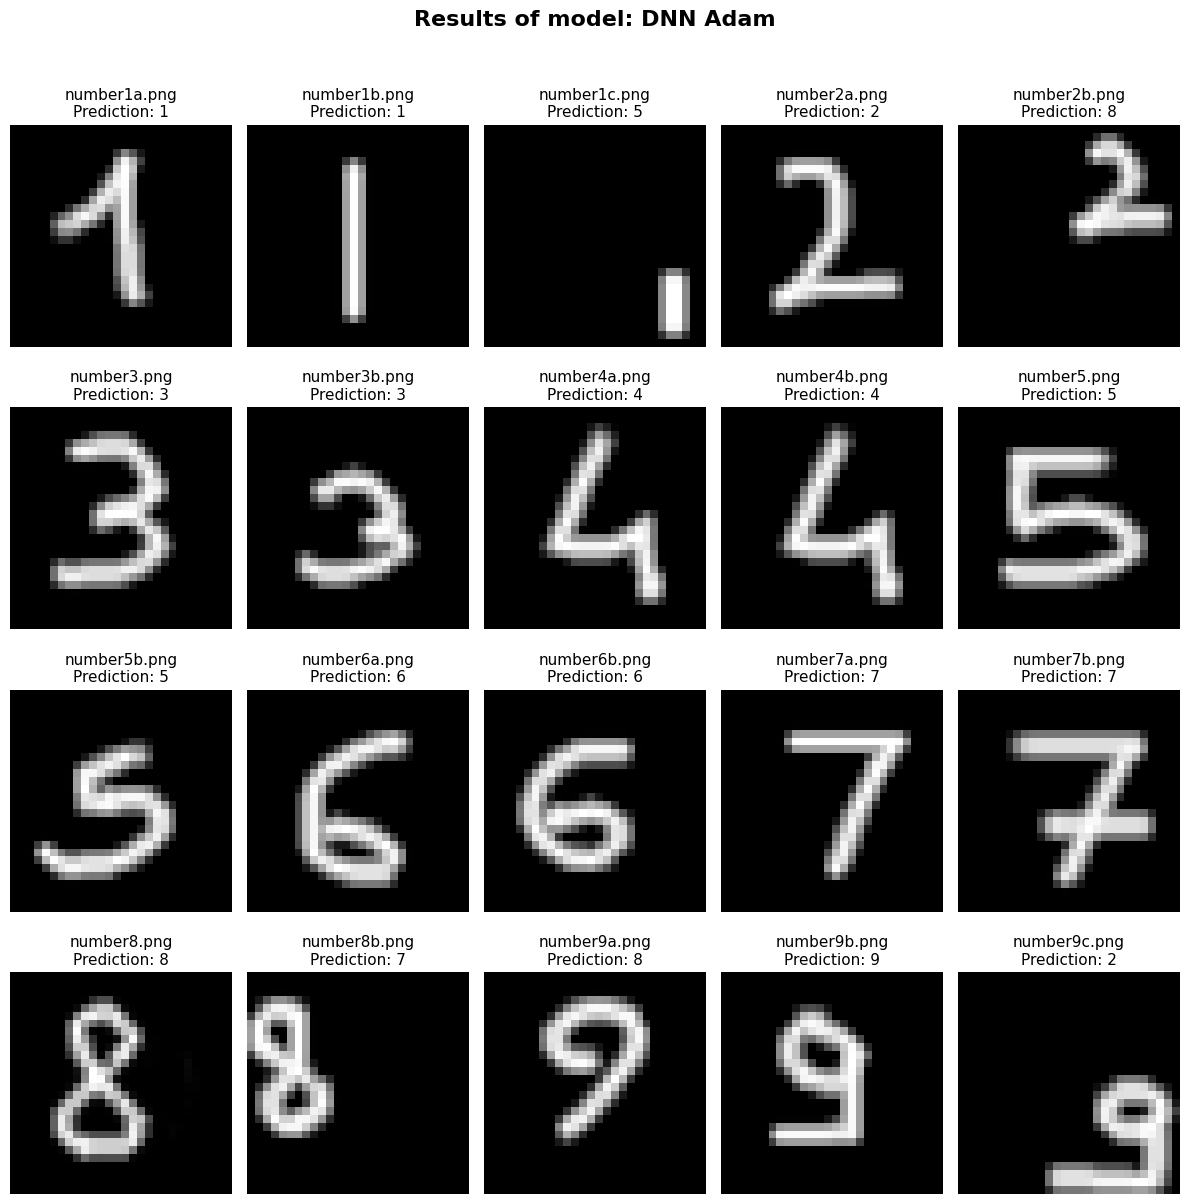

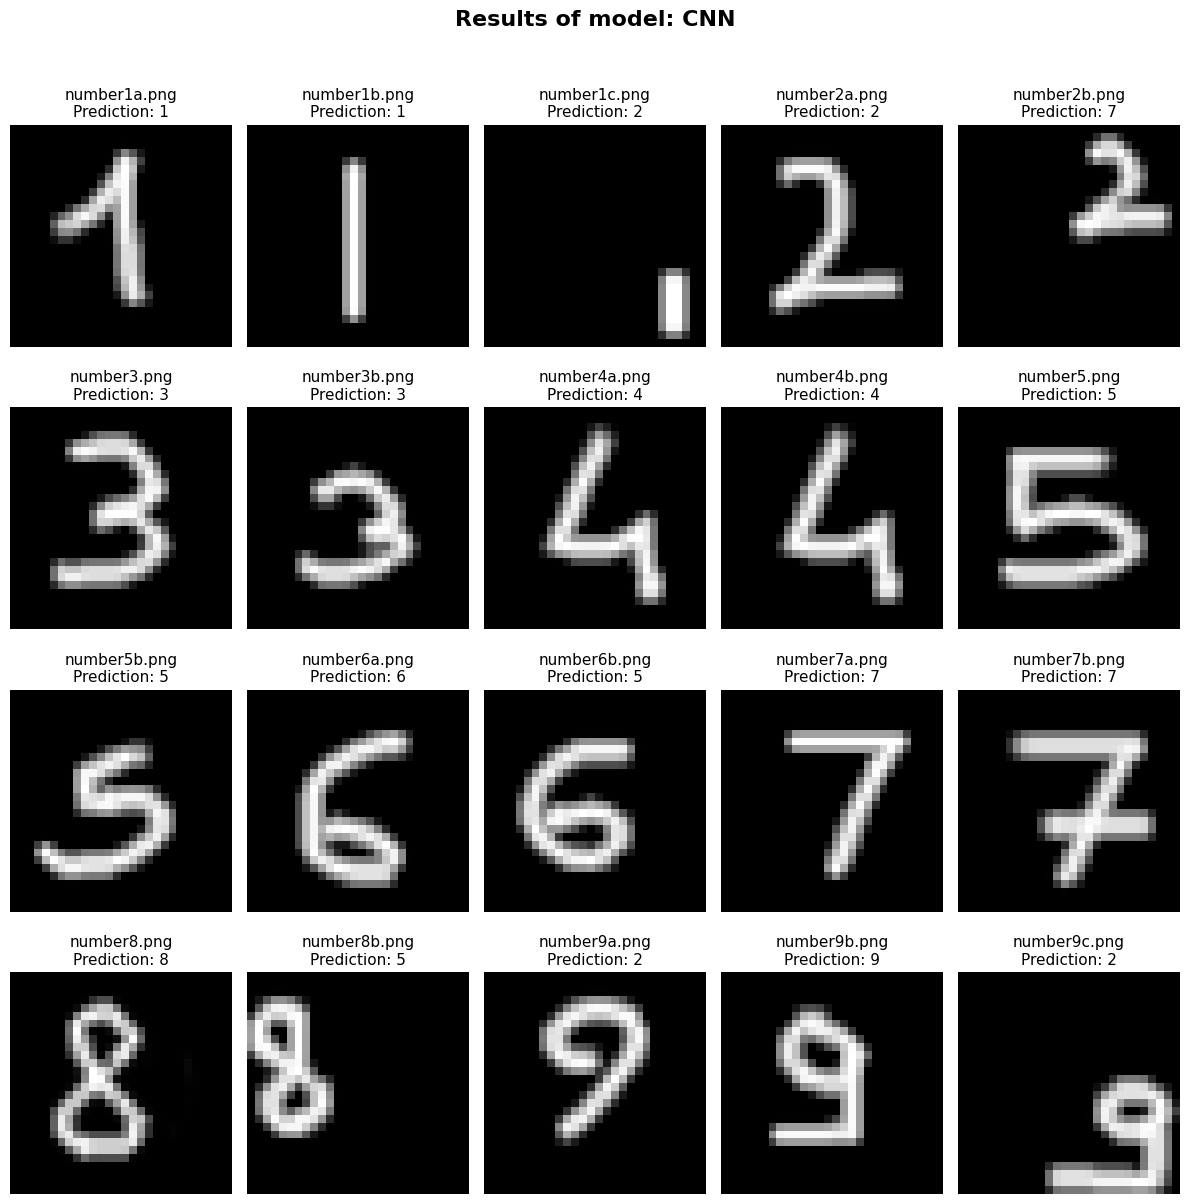

In [419]:
dir = "numbers/"

models = {
    "DNN SGD": model_DNN_SGD, 
    "DNN Adam": model_DNN_adam,        
    "CNN": model_CNN       
}

image_files = os.listdir(dir)
image_files.sort()
n_images = len(image_files)

columns = 5
rows = math.ceil(n_images / columns)

# Loop over the models
for model_name, model in models.items():
    
    # Figure for the current model
    plt.figure(figsize=(12, 3 * rows))
    plt.suptitle(f"Results of model: {model_name}", fontsize=16, fontweight='bold', y=1.02)
    
    # Loop over the images
    for i, file_name in enumerate(image_files):
        path = os.path.join(dir, file_name)
        
        img = Image.open(path).convert('L')
        data = np.array(img) / 255.0
        
        # Prepare the data according to the type of network
        if "DNN" in model_name:
            data_input = data.reshape(1, 28 * 28)
        else:
            data_input = data.reshape(1, 28, 28, 1)
            
        # Prediction
        pred = model.predict(data_input, verbose=0)
        predicted_digit = np.argmax(pred)
        
        plt.subplot(rows, columns, i + 1)
        plt.imshow(data, cmap='gray')
        
        plt.title(f"{file_name}\nPrediction: {predicted_digit}", fontsize=11)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()